In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
adata= sc.read_h5ad('all_kinetics_adata.h5ad')

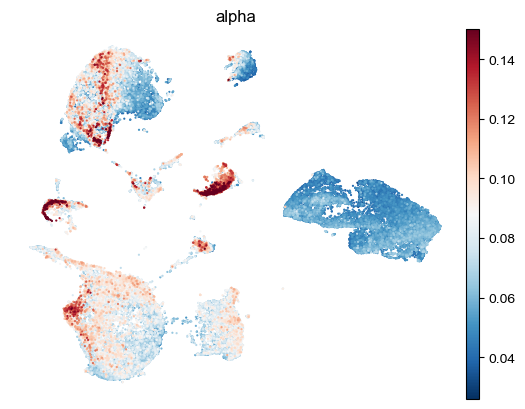

In [6]:
sc.pl.umap(adata, color='alpha', 
           cmap='RdBu_r', 
           vmax=0.15,
           s =10,
           frameon=False,
           show=True)

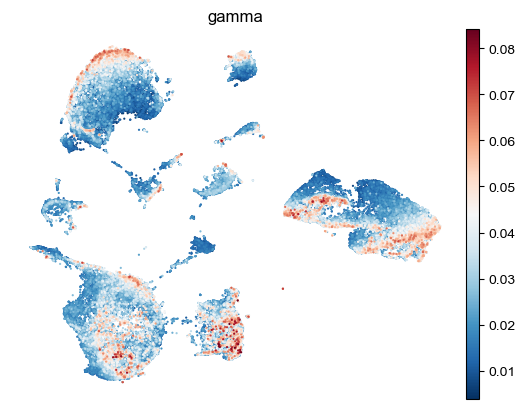

In [7]:
sc.pl.umap(adata, color='gamma', 
           cmap='RdBu_r', 
           s =10,
           frameon=False,
           show=True)

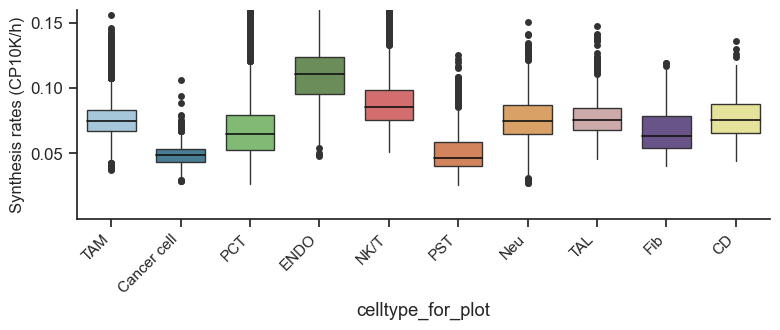

In [8]:

name_mapping = {
    'Macrophage': 'TAM',
    'cancer cell': 'Cancer cell',
    'PCT': 'PCT',
    'ENDO': 'ENDO',
    'NK_T': 'NK/T',
    'PST': 'PST',
    'Neutrophil': 'Neu',
    'TAL': 'TAL',
    'Fibroblast': 'Fib',
    'CDIC_CDPC': 'CD'
}

adata.obs['celltype_for_plot'] = adata.obs['celltype1'].map(name_mapping)

custom_palette = {
    'TAM': '#9ECAE1',         
    'Cancer cell': '#3B82A0', 
    'PCT': '#78C668',         
    'ENDO': '#689552',        
    'NK/T': '#E55D5D',        
    'PST': '#E67D48',         
    'Neu': '#EDA154',         
    'TAL': '#D4A5A5',         
    'Fib': '#674B92',         
    'CD': '#F1EE8E'           
}

cell_order = ['TAM', 'Cancer cell', 'PCT', 'ENDO', 'NK/T', 'PST', 'Neu', 'TAL', 'Fib', 'CD']

plt.figure(figsize=(8, 3.5)) 
sns.set_theme(style="ticks", font_scale=1.1)

ax = sns.boxplot(
    data=adata.obs, 
    x='celltype_for_plot',       
    y='alpha', 
    order=cell_order,            
    palette=custom_palette,      
    width=0.7,                   
    linewidth=1,                 
    showcaps=False,              
    showfliers=True,             
    flierprops={
        'marker': 'o', 
        'markersize': 5, 
        'markerfacecolor': '#333333', 
        'markeredgecolor': 'none',
        'alpha': 1
    },                           
    boxprops={'edgecolor': '#333333'},
    whiskerprops={'color': '#333333'},
    medianprops={'color': '#111111', 'linewidth': 1.2} 
)

plt.ylim(0, 0.16)
plt.yticks([ 0.05, 0.10, 0.15])

plt.ylabel('Synthesis rates (CP10K/h)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('fig4_boxplot.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

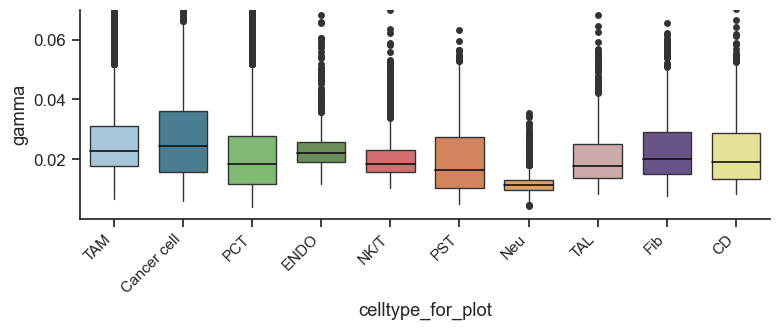

In [14]:
plt.figure(figsize=(8, 3.5)) 
sns.set_theme(style="ticks", font_scale=1.1)
ax = sns.boxplot(
    data=adata.obs, 
    x='celltype_for_plot',       
    y='gamma', 
    order=cell_order,            
    palette=custom_palette,      
    width=0.7,                   
    linewidth=1,                 
    showcaps=False,              
    showfliers=True,             
    flierprops={
        'marker': 'o', 
        'markersize': 5, 
        'markerfacecolor': '#333333', 
        'markeredgecolor': 'none',
        'alpha': 1
    },                           
    boxprops={'edgecolor': '#333333'},
    whiskerprops={'color': '#333333'},
    medianprops={'color': '#111111', 'linewidth': 1.2} 
)

plt.ylim(0, 0.07)
plt.yticks([0.02,0.04,0.06])

plt.xticks(rotation=45, ha='right', fontsize=11)
sns.despine()

plt.tight_layout()
plt.savefig('fig4_boxplot_gamma.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()